In [ ]:
import pandas as pd
import random
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel, BertConfig, BertModel
# import adapters
# from adapters import AutoAdapterModel
import gc
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib

import pickle
import time
import memory_profiler

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

from text_visualizations.train_stuff import (
    fix_all_seeds,
)
from text_visualizations.config_helpers import load_config

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")

In [ ]:
plt.style.use("matplotlib_style.txt")

In [ ]:
%watermark -t -d -tz -u -v -iv -w -m -h -p transformers -p openTSNE
print(distro.name(pretty=True))

Last updated: 2025-04-10 16:11:24CEST

Python implementation: CPython
Python version       : 3.12.1
IPython version      : 9.0.2

openTSNE: not installed

Compiler    : GCC 8.5.0 20210514 (Red Hat 8.5.0-21)
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: gber7

matplotlib         : 3.10.1
transformers       : 4.50.2
black              : 25.1.0
text_visualizations: 0.1.0
pathlib            : 1.0.1
jupyter_black      : 0.4.0
memory_profiler    : 0.61.0
distro             : 1.9.0
sklearn            : 1.6.1
numpy              : 2.1.3
torch              : 2.6.0
pandas             : 2.2.3

Watermark: 2.5.0

Rocky Linux 8.10 (Green Obsidian)


# Import

In [ ]:
%%time
iclr = pd.read_parquet(
    data_path / "iclr25v2.parquet",
    engine="fastparquet",  # "pyarrow",
)

CPU times: user 111 ms, sys: 47.1 ms, total: 158 ms
Wall time: 159 ms


In [ ]:
print(iclr.keywords.iloc[0])
print(type(iclr.keywords.iloc[0]))
print(iclr.scores.iloc[0])
print(type(iclr.scores.iloc[0]))

['deep learning', 'transfer learning']
<class 'list'>
[np.int64(6), np.int64(4), np.int64(5)]
<class 'list'>


In [ ]:
iclr.keywords = iclr.keywords.transform(lambda x: list(x))
iclr.scores = iclr.scores.transform(lambda x: list(x))

In [ ]:
print(iclr.keywords.iloc[0])
print(type(iclr.keywords.iloc[0]))
print(iclr.scores.iloc[0])
print(type(iclr.scores.iloc[0]))

['deep learning', 'transfer learning']
<class 'list'>
[np.int64(6), np.int64(4), np.int64(5)]
<class 'list'>


In [ ]:
iclr

,year,id,title,abstract,authors,decision,scores,keywords,labels
0,2017,B1-Hhnslg,Prototypical Networks for Few-shot Learning,A recent approach to few-shot classification c...,"Jake Snell, Kevin Swersky, Richard Zemel",Reject,"[6, 4, 5]","[deep learning, transfer learning]",transfer learning
1,2017,B1-q5Pqxl,Machine Comprehension Using Match-LSTM and Ans...,Machine comprehension of text is an important ...,"Shuohang Wang, Jing Jiang",Accept (Poster),"[6, 6, 7]","[natural language processing, deep learning]",language models
2,2017,B16Jem9xe,Learning in Implicit Generative Models,Generative adversarial networks (GANs) provide...,"Shakir Mohamed, Balaji Lakshminarayanan",Invite to Workshop Track,"[8, 7, 6]",[unsupervised learning],unlabeled
3,2017,B16dGcqlx,Third Person Imitation Learning,Reinforcement learning (RL) makes it possible ...,"Bradly C Stadie, Pieter Abbeel, Ilya Sutskever",Accept (Poster),"[6, 5, 6]",[],unlabeled
4,2017,B184E5qee,Improving Neural Language Models with a Contin...,We propose an extension to neural network lang...,"Edouard Grave, Armand Joulin, Nicolas Usunier",Accept (Poster),"[7, 9, 5]",[natural language processing],language models
...,...,...,...,...,...,...,...,...,...
34519,2025,zxO4WuVGns,Inverse decision-making using neural amortized...,Bayesian observer and actor models have provid...,"Dominik Straub, Tobias F. Niehues, Jan Peters,...",Accept (Poster),"[6, 6, 6]","[bayesian actor models, perception and action,...",unlabeled
34520,2025,zxbQLztmwb,Emergent Symbol-Like Number Variables in Artif...,There is an open question of what types of num...,"Satchel Grant, Noah Goodman, James Lloyd McCle...",Reject,"[3, 5, 6, 5]","[mechanistic interpretability, numeric cogniti...",unlabeled
34521,2025,zxqdVo9FjY,Generalization for Least Squares Regression wi...,Random matrix theory has proven to be a valuab...,"Jiping Li, Rishi Sonthalia",Reject,"[5, 3, 5, 5, 6]","[generalization, random matrix theory, spiked ...",unlabeled
34522,2025,zyGrziIVdE,Exploration by Running Away from the Past,The ability to explore efficiently and effecti...,"Paul-Antoine LE TOLGUENEC, Yann Besse, Florent...",Reject,"[3, 3, 5, 3]","[reinforcement learning, exploration, deep lea...",RL


In [ ]:
iclr.abstract[iclr.labels != "unlabeled"]

0        A recent approach to few-shot classification c...
1        Machine comprehension of text is an important ...
4        We propose an extension to neural network lang...
5        We look at the eigenvalues of the Hessian of a...
7        We introduce the adversarially learned inferen...
                               ...                        
34515    In the era of vision Transformers, the recent ...
34516    Adapter-tuning strategy is an efficient method...
34517    Spiking Neural Networks (SNNs) enable energy-e...
34518    Multivariate time series data and their models...
34522    The ability to explore efficiently and effecti...
Name: abstract, Length: 18892, dtype: object

In [ ]:
pickle_in = open(
    data_path / "dict_label_to_color.pkl",
    "rb",
)
dict_label_to_color = pickle.load(pickle_in)

In [ ]:
colors_iclr = np.vectorize(dict_label_to_color.get)(iclr.labels)

# Playground

In [ ]:
hidden_dims = [1]

In [ ]:
from text_visualizations.models import ModelProjector
from text_visualizations.train_stuff import mean_pool

In [ ]:
test_model = ModelProjector(
    "sentence-transformers/all-mpnet-base-v2",
    mean_pool,
    hidden_dims=[1536, 2],
    output_dim=2,
)

In [ ]:
test_model

NameError: name 'test_model' is not defined

### Test load configs

In [ ]:
configs_path = Path("../configs")

In [ ]:
from text_visualizations.config_helpers import load_config

In [ ]:
config = load_config("exp001.yaml", configs_dir_path=configs_path)

In [ ]:
config

{'model': {'model_name': 'SBERT',
  'model_path': 'sentence-transformers/all-mpnet-base-v2',
  'pooler': 'train_stuff.mean_pool',
  'in_dim': 768,
  'hidden_dims': 1536,
  'output_dim': 2},
 'data_loader': {'dataset': 'ICLR', 'batch_size': 64, 'n_cons_sntcs': 2},
 'training': {'eval_every_epochs': True,
  'eval_every_batches': 0,
  'eval_function': 'eval_functions.KNNEval',
  'eval_rep': 'None',
  'dist_metric': 'euclidean',
  'mteb_tasks': 'None',
  'n_epochs': 10,
  'lr': '2e-5',
  'scale': 20.0}}

In [ ]:
import yaml


with open("../configs/exp001.yaml", "r") as f:
    base_config = yaml.safe_load(f)
base_config

{'model': {'model_name': 'new MODel'}, 'data_loader': None, 'training': None}

In [ ]:
base_config["model"]

{'model_name': 'new MODel'}

In [ ]:
isinstance(base_config["data_loader"], dict)

False

In [ ]:
from copy import deepcopy
from text_visualizations.config_helpers import deep_update

result = deepcopy(base_dict)

for key, value in update_dict.items():
    # If the value is a nested dictionary, recurse
    if (
        isinstance(value, dict)
        and key in result
        and isinstance(result[key], dict)
    ):
        result[key] = deep_update(result[key], value)
    elif value is not None:
        # Otherwise just update the value
        result[key] = value

In [ ]:
result

{'model': {'model_name': 'new MODel',
  'model_path': 'sentence-transformers/all-mpnet-base-v2',
  'in_dim': 768,
  'hidden_dims': 1536,
  'output_dim': 2},
 'data_loader': {'batch_size': 64},
 'training': {'eval_every_epochs': True,
  'eval_every_batches': 0,
  'eval_rep': 'None',
  'dist_metric': 'euclidean',
  'mteb_tasks': 'None',
  'n_epochs': 10,
  'lr': '2e-5',
  'scale': 20.0}}

In [ ]:
config.keys()
config

{'model': [{'model_name': 'new MODel'}], 'data_loader': None, 'training': None}

In [ ]:
config["model"]["model_name"]
config["model"]["model_path"]
config["model"]["in_dim"]
config["model"]["hidden_dims"]
config["model"]["output_dim"]

In [ ]:
config["data_loader"]["batch_size"]
config["data_loader"]["n_cons_sntcs"]


In [ ]:
config["training"]["eval_every_epochs"]
config["training"]["eval_every_batches"]
config["training"]["eval_rep"]
config["training"]["dist_metric"]
config["training"]["mteb_tasks"]
config["training"]["n_epochs"]
config["training"]["lr"]
config["training"]["scale"]

### Pooler

In [ ]:
import importlib

def get_function(function_str):
    """
    Dynamically import pooler function from a module.
    
    Args:
        function_str (str): A string like 'train_stuff.mean_pool' (first python file, second funtion name, separated by a dot) 
    """
    assert isinstance(function_str, str), "Input must be a string of the format 'train_stuff.mean_pool'"
    
    # Handle simple string case like 'poolers.mean_pooler'
    module_path, function_name = function_str.rsplit('.', 1)
    module_path = "text_visualizations." + module_path
    module = importlib.import_module(module_path)

    return getattr(module, function_name)


In [ ]:
# import text_visualizations
# import text_visualizations.train_stuff


a = get_function('train_stuff.mean_pool')

In [ ]:
a

<function text_visualizations.train_stuff.mean_pool(token_embeds, attention_mask)>

In [ ]:
from text_visualizations.train_stuff import mean_pool
b = mean_pool

In [ ]:
b

<function text_visualizations.train_stuff.mean_pool(token_embeds, attention_mask)>

### File name

In [ ]:
config_path = "exp001.yaml"

In [ ]:
import os
exp_name = os.path.basename(config_path).split('.')[0]
exp_name

'exp001'

In [ ]:
def create_results_path(exp_config_path, config_dict, variables_path):
    """
    Name example: variables_path/sbert/iclr/exp001
    
    """

    # Extract experiment name from config file path
    exp_name = os.path.basename(config_path).split('.')[0]

    results_dir = variables_path / Path(model_name / exp_name)
    results_dir.mkdir(parents=True, exist_ok=True)

    revariables_path / 
    
    # Create results directory if it doesn't exist
    results_dir = os.path.join('results', exp_name)
    os.makedirs(results_dir, exist_ok=True)
    
    # Add metadata
    merged_config['timestamp'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    merged_config['base_config'] = base_config_path
    merged_config['experiment_config'] = config_path
    
    # Save merged configuration to results directory for reproducibility
    with open(os.path.join(results_dir, 'config.yaml'), 'w') as f:
        yaml.dump(merged_config, f, default_flow_style=False, sort_keys=False)
    
    return results_dir

In [ ]:
saving_path = (
Path(config["model"]['model_name'].lower())
    / Path(config["data_loader"]['dataset'].lower())
    / Path(exp_name)
)


In [ ]:
saving_path

PosixPath('new model/iclr/exp001')

### Add losses

In [ ]:
a = np.ones((3, 10))
print(a)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [ ]:
np.mean(a, axis=1).shape
np.mean(a, axis=1)

array([1., 1., 1.])

In [ ]:
np.mean(a[0])

np.float64(1.0)

In [ ]:
import time
# import sleep

start = time.time()
for i in range(2):
    time.sleep(1)
end = time.time()

print(start)
print(end)
print(end-start)

1743672733.5365684
1743672735.5372045
2.000636100769043


In [ ]:
from datetime import datetime

datetime.now().strftime("%Y-%m-%d %H:%M:%S")
datetime.now().strftime("%Y%m%d_%H%M%S")

'20250404_102818'

In [ ]:
from datetime import timedelta

def convert_seconds_using_timedelta(seconds):
    td = timedelta(seconds=seconds)
    return str(td)

# Example usage
print(convert_seconds_using_timedelta(5000))  # Output: "1:23:20"

1:23:20


In [ ]:
# from datetime import timedelta
from datetime import datetime, timedelta

str(timedelta(seconds=5000))

  # Output: "1:23:20"

'1:23:20'

In [ ]:
from text_visualizations.config_helpers import get_git_commit_hash
get_git_commit_hash()

'e0a8e8a6fa4091a55895616892926e2b9fde3847'

### 2D embeddings test

In [ ]:
from text_visualizations.models import ModelProjector, ModelProjectorWrapper
from text_visualizations.train_stuff import mean_pool

In [ ]:
model = ModelProjector(
    "sentence-transformers/all-mpnet-base-v2",
    mean_pool,
    hidden_dims=[1536, 2],
    output_dim=2,
)

tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-mpnet-base-v2"
)

In [ ]:
wrapped_model = ModelProjectorWrapper(model, tokenizer)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on device: {}".format(device))

wrapped_model.model.to(device)

Running on device: cuda


ModelProjector(
  (backbone): MPNetModel(
    (embeddings): MPNetEmbeddings(
      (word_embeddings): Embedding(30527, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): MPNetEncoder(
      (layer): ModuleList(
        (0-11): 12 x MPNetLayer(
          (attention): MPNetAttention(
            (attn): MPNetSelfAttention(
              (q): Linear(in_features=768, out_features=768, bias=True)
              (k): Linear(in_features=768, out_features=768, bias=True)
              (v): Linear(in_features=768, out_features=768, bias=True)
              (o): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
  

In [ ]:
import datasets
from tqdm.notebook import tqdm

# abstracts, tokenizer, model, device,  return_seventh = False
batch_size = 256

inputs = tokenizer(
    iclr.abstract.to_list()[:500],
    padding=True,
    truncation=True,
    return_tensors="pt",
    max_length=512,
).to(device)

dataset = datasets.Dataset.from_dict(inputs)
dataset.set_format(type="torch", output_all_columns=True)
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,  # num_workers=10
)


# embedding_av  = []
# embedding_sep = []
# embedding_cls = []

embeddings = []
with torch.no_grad():
    model.eval()
    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        embeddings.append(out.detach().cpu().numpy())
        # token_embeds = out[0]  # get the last hidden state
        # av = mean_pool(token_embeds, batch["attention_mask"])
        # sep = sep_pool(token_embeds, batch["attention_mask"])
        # cls = cls_pool(token_embeds, batch["attention_mask"])
        # embedding_av.append(av.detach().cpu().numpy())
        # embedding_sep.append(sep.detach().cpu().numpy())
        # embedding_cls.append(cls.detach().cpu().numpy())


embeddings = np.vstack(embeddings)
# embedding_sep = np.vstack(embedding_sep)
# embedding_cls = np.vstack(embedding_cls)

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
%%time
_, _, embeddings_2d = wrapped_model.encode_dataset(
    iclr.abstract.to_list(), device=device
)

  0%|          | 0/135 [00:00<?, ?it/s]

CPU times: user 6min 35s, sys: 7.3 s, total: 6min 42s
Wall time: 4min 53s


In [ ]:
embeddings_2d.shape

(34524, 2)

In [ ]:
out.shape

torch.Size([244, 2])

In [ ]:
embeddings.shape

(500, 2)

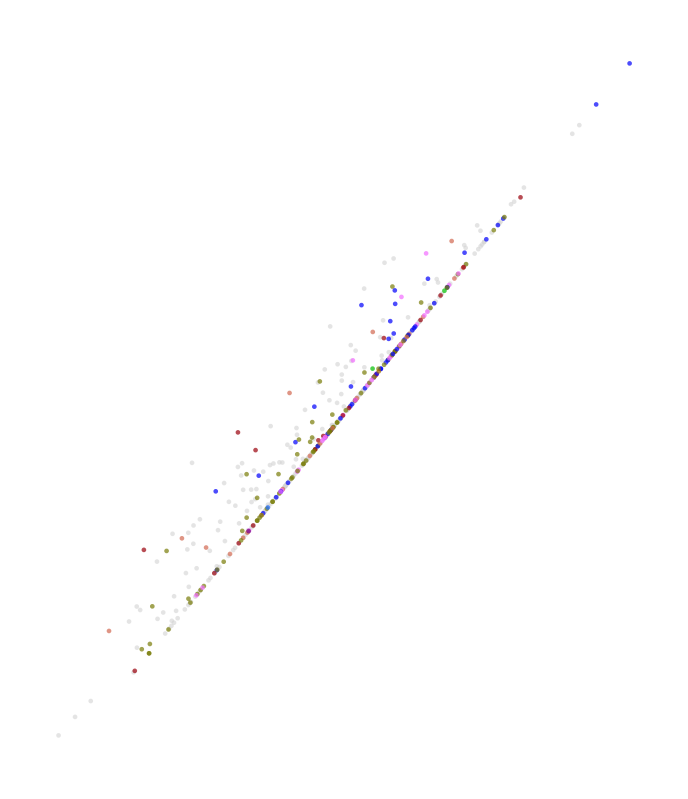

In [ ]:
from text_visualizations.plotting import plot_tsne_colors

plot_tsne_colors(embeddings, colors_iclr[:500])

In [ ]:
%%time
_, _, iclr_2d = wrapped_model.encode_dataset(
    iclr.abstract.to_list()[:500], device=device
)

  0%|          | 0/2 [00:00<?, ?it/s]

CPU times: user 7.53 s, sys: 56.2 ms, total: 7.59 s
Wall time: 5.77 s


In [ ]:
iclr_2d.shape

(500, 2)

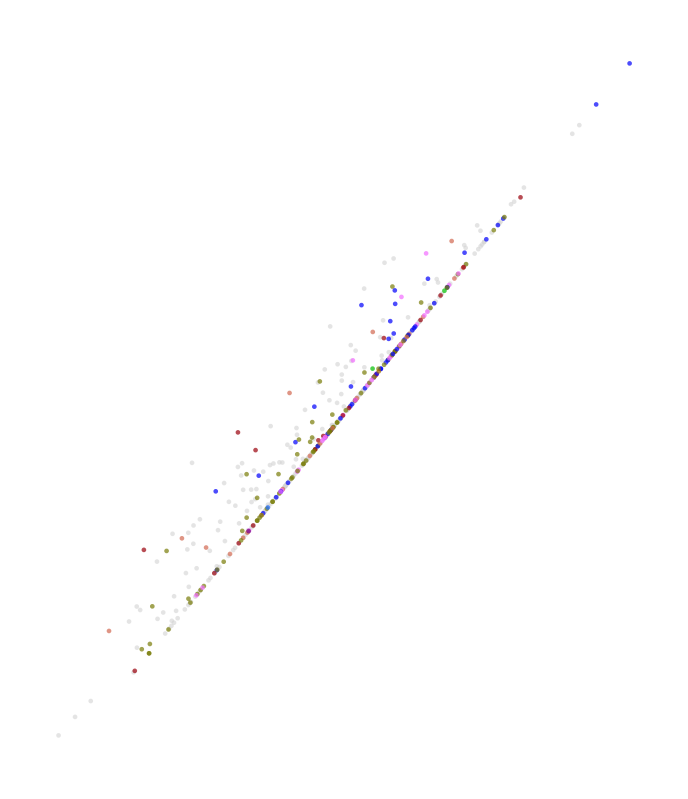

In [ ]:
from text_visualizations.plotting import plot_tsne_colors

plot_tsne_colors(iclr_2d, colors_iclr[:500])

### test model save and load

In [ ]:
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import os
import datasets
import numpy as np
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer, models
from tqdm.notebook import tqdm

class ModelProjector(nn.Module):
    """Model that projects to 2D
    Very similar to ModelWithProjectionHead, only changing the projection head.
    """
    def __init__(self, checkpoint, pooler, hidden_dims, in_dim=768, output_dim=2, freeze_backbone=False):
        super().__init__()  # to inherit from the nn.Module
        self.pooler = pooler  # pooler function
        self.checkpoint = checkpoint
        self.in_dim = in_dim
        self.output_dim = output_dim
        self.hidden_dims = [hidden_dims] if not isinstance(hidden_dims, list) else hidden_dims

        # load model
        self.backbone = AutoModel.from_pretrained(
                checkpoint
            )
        
        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # create projection head
        layers = []
        ## input layer
        layers.append(nn.Linear(self.in_dim, self.hidden_dims[0]))
        layers.append(nn.ReLU())

        ## hidden layers
        for i in range(1,len(self.hidden_dims)):
            layers.append(nn.Linear(self.hidden_dims[i-1], self.hidden_dims[i]))
            layers.append(nn.ReLU(inplace=True))

        ## output layer
        layers.append(nn.Linear(self.hidden_dims[-1], self.output_dim))

        # add projection head
        self.projection_head = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask):
        """
        pooler : {mean_pool, cls_pool, sep_pool, seventh_pool?}
        """
        # Extract outputs from the body
        outputs = self.backbone(
            input_ids=input_ids, attention_mask=attention_mask
        )[0]

        # pooling
        h = self.pooler(outputs, attention_mask)

        # Add custom layers
        z = self.projection_head(h)  # .view(-1,768)

        return z
    
    def save_model(self, filepath, include_pooler=False):
        """
        Save the model's state dictionary and configuration to a file
        
        Args:
            filepath: Path where to save the model
            include_pooler: Whether to try saving the pooler function (only works for simple functions)
        """
        # Save model configuration along with state dict
        save_dict = {
            'state_dict': self.state_dict(),
            'config': {
                'checkpoint': self.checkpoint,
                'in_dim': self.in_dim,
                'hidden_dims': self.hidden_dims,
                'output_dim': self.output_dim,
                'freeze_backbone': any(not p.requires_grad for p in self.backbone.parameters())
            }
        }
        
        # Try to save pooler if requested (may not work for all pooler functions)
        if include_pooler:
            try:
                import dill
                save_dict['pooler'] = dill.dumps(self.pooler)
                print("Pooler function serialized successfully")
            except Exception as e:
                print(f"Warning: Could not serialize pooler function: {e}")
                print("You'll need to provide the pooler function when loading")
        
        torch.save(save_dict, filepath)
        print(f"Model saved to {filepath}")
    
    @classmethod
    def load_model(cls, filepath, pooler=None, device=None):
        """
        Load a model from a saved file with configuration
        
        Args:
            filepath: Path to the saved model file
            pooler: Pooling function to use (required if not saved or can't be deserialized)
            device: Device to load the model to (default: None)
            
        Returns:
            model: Loaded model instance
        """
        # Load the saved dictionary
        if device is None:
            save_dict = torch.load(filepath)
        else:
            save_dict = torch.load(filepath, map_location=device)
        
        # Extract configuration
        config = save_dict['config']
        
        # Try to load saved pooler if present
        if 'pooler' in save_dict and pooler is None:
            try:
                import dill
                pooler = dill.loads(save_dict['pooler'])
                print("Pooler function loaded successfully")
            except Exception as e:
                print(f"Warning: Could not deserialize saved pooler function: {e}")
                if pooler is None:
                    raise ValueError("Pooler function is required but couldn't be loaded from file. Please provide one.")
        
        if pooler is None:
            raise ValueError("Pooler function is required but not provided and not found in saved file")
        
        # Create a new model with the saved configuration
        model = cls(
            checkpoint=config['checkpoint'],
            pooler=pooler,
            hidden_dims=config['hidden_dims'],
            in_dim=config['in_dim'],
            output_dim=config['output_dim'],
            freeze_backbone=config.get('freeze_backbone', False)
        )
        
        # Load the state dictionary
        model.load_state_dict(save_dict['state_dict'])
        
        # Move to specified device if provided
        if device is not None:
            model = model.to(device)
        
        print(f"Model loaded from {filepath}")
        return model

In [ ]:
# from text_visualizations.models import ModelProjector
from text_visualizations.train_stuff import mean_pool

In [ ]:
from text_visualizations.models import ModelProjectorWrapper


In [ ]:
test_model = ModelProjector(
    "sentence-transformers/all-mpnet-base-v2",
    mean_pool,
    hidden_dims=[1536, 2],
    output_dim=2,
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
wrapped_model = ModelProjectorWrapper(test_model, tokenizer)

In [ ]:
# Save the entire model
wrapped_model.model.save_model("complete_model.pt", include_pooler=True)

Pooler function serialized successfully
Model saved to complete_model.pt


In [ ]:
# Load model with minimal parameters
try:
    # Try to load with saved pooler
    loaded_model = ModelProjector.load_model(
        filepath="complete_model.pt",
        # device="cuda" if torch.cuda.is_available() else "cpu"
    )
except ValueError:
    # If pooler couldn't be loaded, provide it explicitly
    # from text_visualizations.train_stuff import mean_pool  

    loaded_model = ModelProjector.load_model(
        filepath="complete_model.pt",
        pooler=mean_pool,
        # device="cuda" if torch.cuda.is_available() else "cpu"
    )

Pooler function loaded successfully
Model loaded from complete_model.pt


In [ ]:
def compare_model_weights(model1, model2, atol=1e-7, verbose=True):
    """
    Compare the weights of two ModelProjector instances to check if they're identical
    
    Args:
        model1: First ModelProjector instance
        model2: Second ModelProjector instance
        atol: Absolute tolerance for floating point comparisons
        verbose: Whether to print detailed comparison results
        
    Returns:
        bool: True if weights are identical, False otherwise
    """
    weights_identical = True
    differences = []
    
    # Get state dictionaries (model weights)
    state_dict1 = model1.state_dict()
    state_dict2 = model2.state_dict()
    
    # Check if they have the same keys
    if set(state_dict1.keys()) != set(state_dict2.keys()):
        missing_in_2 = set(state_dict1.keys()) - set(state_dict2.keys())
        missing_in_1 = set(state_dict2.keys()) - set(state_dict1.keys())
        if verbose:
            if missing_in_2:
                differences.append(f"Keys missing in model2: {missing_in_2}")
            if missing_in_1:
                differences.append(f"Keys missing in model1: {missing_in_1}")
        weights_identical = False
    else:
        # Check if the parameter values are the same
        for key in state_dict1:
            if not torch.allclose(state_dict1[key], state_dict2[key], atol=atol):
                if verbose:
                    # Calculate max difference for informational purposes
                    max_diff = (state_dict1[key] - state_dict2[key]).abs().max().item()
                    differences.append(f"Parameters differ for key '{key}' (max difference: {max_diff:.6e})")
                weights_identical = False
    
    # Print differences if verbose
    if verbose and not weights_identical:
        print("Model weights are not identical. Differences found:")
        for diff in differences:
            print(f"- {diff}")
    elif verbose and weights_identical:
        print("Model weights are identical!")
    
    return weights_identical

In [ ]:
weights_match = compare_model_weights(test_model, loaded_model, verbose=True)

print(f"Model weights are identical: {weights_match}")

Model weights are identical!
Model weights are identical: True


### Add embeddings to dataframe

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
a= np.ones((3,2))
print(a)

[[1. 1.]
 [1. 1.]
 [1. 1.]]


In [ ]:
b = np.arange(10)
print(b)

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
df = pd.DataFrame({"b": b})
df

,b
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [ ]:
list_a = []
list_c = []
for elem in b:
    list_a.append(a)
    list_c.append(["hi", "hey"])

print(list_a)
print(list_c)

[array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]]), array([[1., 1.],
       [1., 1.],
       [1., 1.]])]
[['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey'], ['hi', 'hey']]


In [ ]:
df["a"] = list_a
df

,b,a
0,0,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
1,1,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
2,2,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
3,3,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
4,4,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
5,5,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
6,6,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
7,7,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
8,8,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"
9,9,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]"


In [ ]:
df["c"] = list_c
df

,b,a,c
0,0,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
1,1,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
2,2,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
3,3,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
4,4,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
5,5,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
6,6,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
7,7,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
8,8,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
9,9,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"


In [ ]:
df

,b,a,c
0,0,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
1,1,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
2,2,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
3,3,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
4,4,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
5,5,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
6,6,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
7,7,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
8,8,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
9,9,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"


In [ ]:
df.to_csv(
    "df_test",
    index=False,
)

In [ ]:
df_csv = pd.read_csv("df_test")

In [ ]:
df_csv

,b,c,a
0,0,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
1,1,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
2,2,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
3,3,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
4,4,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
5,5,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
6,6,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
7,7,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
8,8,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]
9,9,"['hi', 'hey']",[[1. 1.]\n [1. 1.]\n [1. 1.]]


In [ ]:
df.pop("a")
df

,b,c
0,0,"[hi, hey]"
1,1,"[hi, hey]"
2,2,"[hi, hey]"
3,3,"[hi, hey]"
4,4,"[hi, hey]"
5,5,"[hi, hey]"
6,6,"[hi, hey]"
7,7,"[hi, hey]"
8,8,"[hi, hey]"
9,9,"[hi, hey]"


In [ ]:
df.to_parquet(
    "df_test",
    index=False,
    # engine="fastparquet",
    # compression="gzip",
)

In [ ]:
type(df.a.iloc[0])

numpy.ndarray

In [ ]:
df.to_hdf("data.h5", key="df", mode="w")  # Save
df_loaded = pd.read_hdf("data.h5")  # Load

/tmp/ipykernel_2826784/76411565.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['a', 'c'], dtype='object')]

  df.to_hdf("data.h5", key="df", mode="w")  # Save


In [ ]:
df_loaded

,b,a,c
0,0,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
1,1,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
2,2,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
3,3,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
4,4,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
5,5,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
6,6,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
7,7,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
8,8,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"
9,9,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[hi, hey]"


In [ ]:
type(df_loaded.a.iloc[0])

numpy.ndarray

### incremental savings

In [ ]:
a= np.ones((3,2))
print(a)

[[1. 1.]
 [1. 1.]
 [1. 1.]]


In [ ]:
b = np.arange(10)
print(b)

[0 1 2 3 4 5 6 7 8 9]


In [ ]:

dict_pd = {}
dict_pd["a"]= []
dict_pd["b"]= []
dict_pd["c"]= []
# pd.DataFrame(dict_pd).to_hdf("data.h5", key="df", mode="w", format="table")

for elem in b:
    dict_pd = {}
    dict_pd["a"] = [a]
    dict_pd["b"] = [b]
    dict_pd["c"] = [["hi", "hey"]]

    # Subsequent appends  
    pd.DataFrame(dict_pd).to_hdf("data.h5", key="df")#, mode="w", format="table")#, append=True)  



/tmp/ipykernel_2826784/62402899.py:14: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['a', 'b', 'c'], dtype='object')]

  pd.DataFrame(dict_pd).to_hdf("data.h5", key="df")#, mode="w", format="table")#, append=True)


In [ ]:
df_loaded = pd.read_hdf("data.h5") 
df_loaded

,a,b,c
0,"[[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[hi, hey]"


In [ ]:
from datetime import datetime

saving_path = (
    variables_path
    / Path("sbert")
    / Path("iclr")
    / Path("exp003" + "_" + "20250408")
)
df_loaded = pd.read_hdf(saving_path / "training_eval_results.h5")
df_loaded

,epoch,loss,knn
0,0,3.655686,[0.1746031746031746]
1,50,2.957107,[0.2291005291005291]
2,100,2.709281,[0.2328042328042328]
3,150,2.560188,[0.23492063492063492]
4,200,2.450751,[0.24708994708994708]


### New saving

In [ ]:
list_a = [[1]]
list_b = list_a*2
print(list_a)
print(list_b)

[[1]]
[[1], [1]]


In [ ]:
from collections import defaultdict


training_eval_results = defaultdict(list)
eval_results={}
eval_results["knn"] = [1]

[training_eval_results[k].append(v) for k, v in eval_results.items()]
training_eval_results

defaultdict(list, {'knn': [[1]]})

In [ ]:
training_eval_results["knn"] = [elem[0] for elem in training_eval_results["knn"]]
training_eval_results

defaultdict(list, {'knn': [1]})

In [ ]:
import numpy as np

saving_path = (
    variables_path
    / Path("sbert")
    / Path("iclr")
    / Path("exp004" + "_" + "20250410")
)
npz = np.load(saving_path / "interm_embeddings_2d")
# labels = npz["labels"]
npz["embeddings_2d_epoch_0"].shape

(205, 2)

In [ ]:
df_loaded = pd.read_hdf(saving_path / "df_log_training.h5")
df_loaded

,epoch,loss,knn
0,0,3.915145,0.523810
1,2,3.486681,0.380952
2,4,3.410427,0.380952


In [ ]:
np.load(saving_path / "embeddings_2d.npy").shape

(500, 2)

#### Logger

In [ ]:
import numpy as np

In [ ]:
def get_kwargs(a, **kwargs):
    return kwargs

In [ ]:
a=[]
b=2
c="hello"
d=np.ones((2,3))

In [ ]:
get_kwargs(a=a, b=b,c=c,d=d)

{'b': 2,
 'c': 'hello',
 'd': array([[1., 1., 1.],
        [1., 1., 1.]])}

In [ ]:
logger=None
assert logger is not None, "You need to pass a logger"

AssertionError: You need to pass a logger